<a href="https://www.kaggle.com/code/jeffbutt/lung-xray-cnn-gradcam-classifier?scriptVersionId=322749679" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Lung X-Ray Disease Classification
Classes:
   - Lung_Opacity
   - Normal
   - Viral Pneumonia

Goal:
Build a configurable image classification pipeline for X-ray disease classification using transfer learning and rigorous evaluation.

## 01. Setup 

In [1]:
import os
import gc
import json
import math
import random
import hashlib
import warnings
from pathlib import Path
from datetime import datetime

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from PIL import Image, ImageFile

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-28 12:14:07.695209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779970447.880624      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779970447.934432      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779970448.385979      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779970448.386048      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779970448.386053      23 computation_placer.cc:177] computation placer alr

In [6]:
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

## 02. Configuration 
Change MODEL_NAME to choose which model to run.

Options:
```text
 
  "custom_cnn"
  "efficientnetb0"
  "resnet50"
  "densenet121"
   
```

In [9]:
CONFIG = {
    "MODEL_NAME": "efficientnetb0",

    # Hardcoded Kaggle dataset path
    "DATA_DIR": "/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image",

    # Image and training parameters
    "IMAGE_SIZE": (224, 224),
    "BATCH_SIZE": 16,
    "EPOCHS": 12,
    "FINE_TUNE_EPOCHS": 8,

    # Train / validation / test split
    "VALID_SIZE": 0.15,
    "TEST_SIZE": 0.15,

    # Optimization
    "LEARNING_RATE": 1e-4,
    "FINE_TUNE_LEARNING_RATE": 1e-5,

    # Classifier head
    "DROPOUT": 0.35,
    "DENSE_UNITS": 256,

    # Transfer learning options
    "DO_FINE_TUNE": True,
    "FINE_TUNE_LAST_N_LAYERS": 30,

    # Cleaning options
    "VALIDATE_IMAGES": True,
    "REMOVE_DUPLICATES": True,

    # Optional lightweight tuning
    "RUN_LIGHTWEIGHT_TUNING": False,
    "TUNING_EPOCHS": 3,

    # Binary threshold tuning
    "RUN_THRESHOLD_TUNING": True,

    # Output directory
    "OUTPUT_DIR": "/kaggle/working/lung_xray_project"
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

CONFIG

{'MODEL_NAME': 'efficientnetb0',
 'DATA_DIR': '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image',
 'IMAGE_SIZE': (224, 224),
 'BATCH_SIZE': 16,
 'EPOCHS': 12,
 'FINE_TUNE_EPOCHS': 8,
 'VALID_SIZE': 0.15,
 'TEST_SIZE': 0.15,
 'LEARNING_RATE': 0.0001,
 'FINE_TUNE_LEARNING_RATE': 1e-05,
 'DROPOUT': 0.35,
 'DENSE_UNITS': 256,
 'DO_FINE_TUNE': True,
 'FINE_TUNE_LAST_N_LAYERS': 30,
 'VALIDATE_IMAGES': True,
 'REMOVE_DUPLICATES': True,
 'RUN_LIGHTWEIGHT_TUNING': False,
 'TUNING_EPOCHS': 3,
 'RUN_THRESHOLD_TUNING': True,
 'OUTPUT_DIR': '/kaggle/working/lung_xray_project'}

In [10]:
DATA_DIR = Path(CONFIG["DATA_DIR"])

EXPECTED_CLASSES = [
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")

print("Dataset root:", DATA_DIR)
print("Dataset folders:")
print(os.listdir(DATA_DIR))

for class_name in EXPECTED_CLASSES:
    class_path = DATA_DIR / class_name

    if not class_path.exists():
        raise FileNotFoundError(
            f"Expected class folder not found: {class_path}"
        )

print("All expected class folders found.")

Dataset root: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image
Dataset folders:
['Normal', 'Lung_Opacity', 'Viral Pneumonia']
All expected class folders found.


## 03. Build Image Manifest

In [11]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_name in EXPECTED_CLASSES:
    class_dir = DATA_DIR / class_name

    for file_path in class_dir.rglob("*"):
        if file_path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                "filepath": str(file_path),
                "label": class_name
            })

df = pd.DataFrame(records)

print("Total image files found:", len(df))
display(df.head())
display(df["label"].value_counts())

Total image files found: 3475


,filepath,label
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity


label
Normal             1250
Lung_Opacity       1125
Viral Pneumonia    1100
Name: count, dtype: int64

## 04. Validate Images 

In [12]:
def validate_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


if CONFIG["VALIDATE_IMAGES"]:
    df["is_valid"] = df["filepath"].apply(validate_image)

    invalid_df = df[df["is_valid"] == False]

    print("Invalid images found:", len(invalid_df))

    if len(invalid_df) > 0:
        display(invalid_df.head())

    df = (
        df[df["is_valid"] == True]
        .drop(columns=["is_valid"])
        .reset_index(drop=True)
    )

print("Images after validation:", len(df))

Invalid images found: 0
Images after validation: 3475


## 05. Image Metadata 

In [13]:
def get_image_metadata(path):
    try:
        with Image.open(path) as img:
            return pd.Series({
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })
    except Exception:
        return pd.Series({
            "width": np.nan,
            "height": np.nan,
            "mode": None
        })


metadata_df = df["filepath"].apply(get_image_metadata)
df = pd.concat([df, metadata_df], axis=1)

display(df.head())
display(df.groupby("label")[["width", "height"]].describe())
display(df["mode"].value_counts())

,filepath,label,width,height,mode
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB


width                                                 \
                  count   mean  std    min    25%    50%    75%    max   
label                                                                    
Lung_Opacity     1125.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   
Normal           1250.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   
Viral Pneumonia  1100.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   

                 height                                                 
                  count   mean  std    min    25%    50%    75%    max  
label                                                                   
Lung_Opacity     1125.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0  
Normal           1250.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0  
Viral Pneumonia  1100.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0

mode
RGB    3475
Name: count, dtype: int64

## 06. Duplicate Detection and Removal 

In [14]:
def file_md5(path, block_size=65536):
    hasher = hashlib.md5()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            hasher.update(block)

    return hasher.hexdigest()


df["file_hash"] = df["filepath"].apply(file_md5)

duplicate_count = df.duplicated("file_hash").sum()

print("Exact duplicate images found:", duplicate_count)

if duplicate_count > 0:
    duplicate_examples = (
        df[df.duplicated("file_hash", keep=False)]
        .sort_values("file_hash")
    )

    display(duplicate_examples.head(20))


if CONFIG["REMOVE_DUPLICATES"]:
    before = len(df)

    df = (
        df
        .drop_duplicates("file_hash", keep="first")
        .reset_index(drop=True)
    )

    after = len(df)

    print(f"Removed {before - after} duplicate images.")

print("Images after duplicate handling:", len(df))
display(df["label"].value_counts())

Exact duplicate images found: 5


,filepath,label,width,height,mode,file_hash
2420,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,03be7856a3db3784f340718acae7802c
3446,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,03be7856a3db3784f340718acae7802c
2695,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,4e301f5187b2ef96b139446ebbb4aef8
2757,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,4e301f5187b2ef96b139446ebbb4aef8
3109,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,6ffad50473dc45727f6d50500b3f84ea
3275,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,6ffad50473dc45727f6d50500b3f84ea
2707,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,91ba812d0392195c63bc3ca86be8907e
3130,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,91ba812d0392195c63bc3ca86be8907e
2517,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,aae3e8d2598bf1469b319596bce678cc
3417,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,aae3e8d2598bf1469b319596bce678cc


Removed 5 duplicate images.
Images after duplicate handling: 3470


label
Normal             1250
Lung_Opacity       1125
Viral Pneumonia    1095
Name: count, dtype: int64

## 07. Exploratory Data Analysis 

### 07a. Class Distribution 

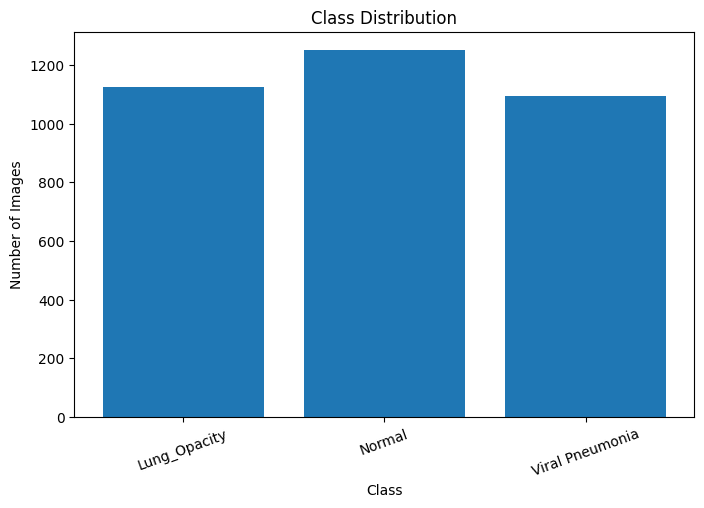

label
Lung_Opacity       1125
Normal             1250
Viral Pneumonia    1095
Name: count, dtype: int64

In [15]:
class_counts = df["label"].value_counts().reindex(EXPECTED_CLASSES)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

display(class_counts)

### 07b. Image Size Distribution

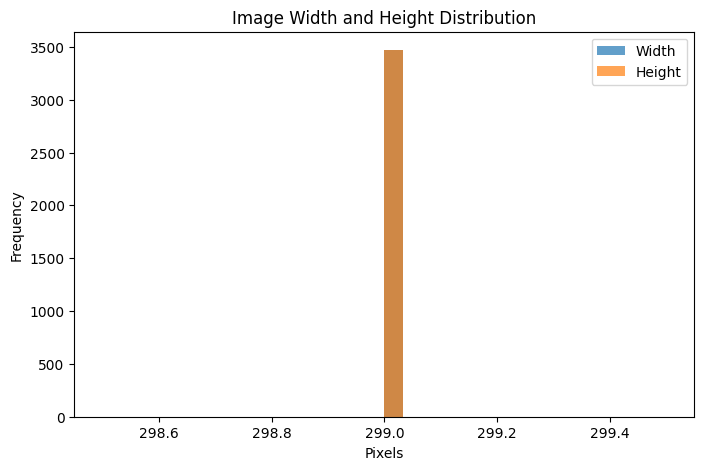

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["width"], bins=30, alpha=0.7, label="Width")
plt.hist(df["height"], bins=30, alpha=0.7, label="Height")
plt.title("Image Width and Height Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 07c. Sample Images 

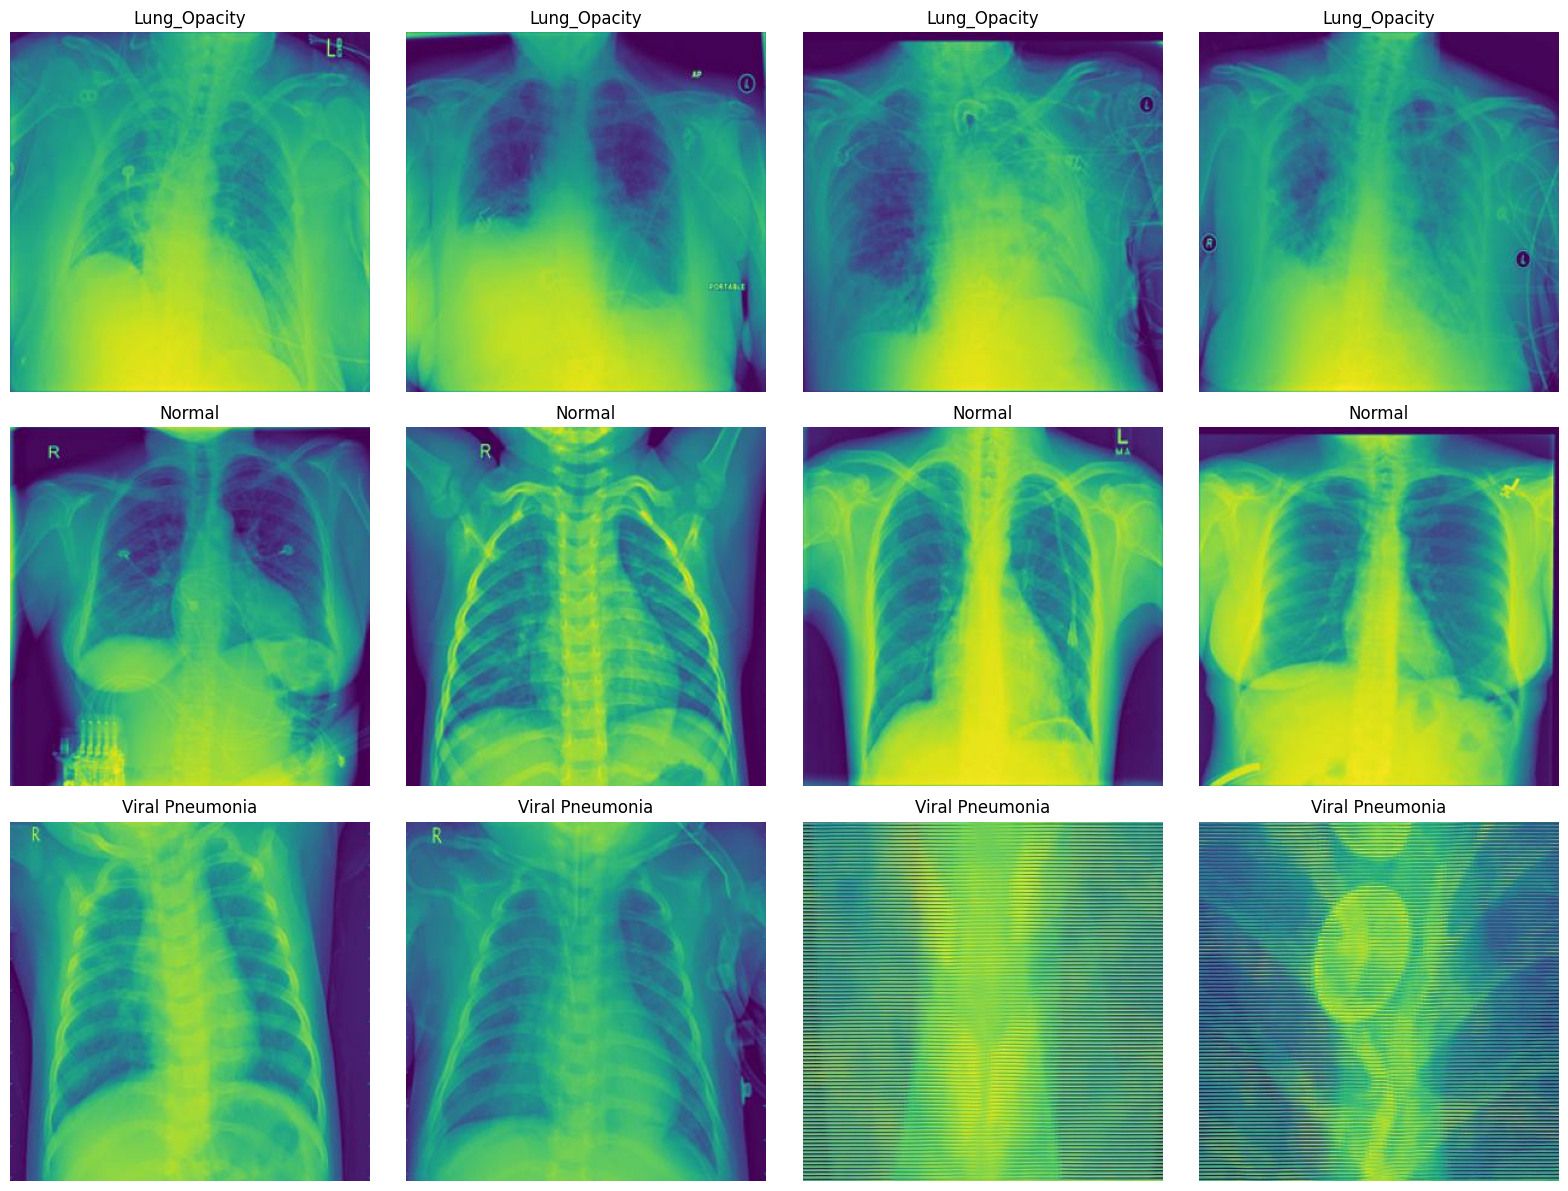

In [17]:
def show_samples(dataframe, class_names, samples_per_class=4):
    rows = len(class_names)
    cols = samples_per_class

    plt.figure(figsize=(cols * 4, rows * 4))

    plot_idx = 1

    for class_name in class_names:
        class_df = dataframe[dataframe["label"] == class_name]

        sample_df = class_df.sample(
            n=min(samples_per_class, len(class_df)),
            random_state=SEED
        )

        for _, row in sample_df.iterrows():
            img = Image.open(row["filepath"]).convert("RGB")

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_samples(df, EXPECTED_CLASSES, samples_per_class=4)

## 08. Label Encoding 

In [18]:
class_names = sorted(df["label"].unique())

class_to_id = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

id_to_class = {
    idx: class_name
    for class_name, idx in class_to_id.items()
}

df["label_id"] = df["label"].map(class_to_id)

NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Class to ID mapping:", class_to_id)
print("Number of classes:", NUM_CLASSES)

display(df.head())

Class names: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Class to ID mapping: {'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}
Number of classes: 3


,filepath,label,width,height,mode,file_hash,label_id
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,3d95207181d4c92619dce1677ba9fc87,0
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,e8a9768f9a1bb721601e67d972c6e8d5,0
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,0c01586302c5b44db53622304a6a37e5,0
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,f43ab9211611b3ac3413dd465be11de9,0
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,5820e7550510823a21571997982af669,0


## 09. Stratified Train / Validation / Test Split 

In [19]:
test_size = CONFIG["TEST_SIZE"]
valid_size = CONFIG["VALID_SIZE"]

train_df, temp_df = train_test_split(
    df,
    test_size=test_size + valid_size,
    stratify=df["label_id"],
    random_state=SEED
)

relative_valid_size = valid_size / (test_size + valid_size)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=1 - relative_valid_size,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train images:", len(train_df))
print("Validation images:", len(valid_df))
print("Test images:", len(test_df))

print("\nTrain distribution:")
display(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
display(valid_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
display(test_df["label"].value_counts(normalize=True))

Train images: 2429
Validation images: 520
Test images: 521

Train distribution:


label
Normal             0.360231
Lung_Opacity       0.324413
Viral Pneumonia    0.315356
Name: proportion, dtype: float64


Validation distribution:


label
Normal             0.359615
Lung_Opacity       0.323077
Viral Pneumonia    0.317308
Name: proportion, dtype: float64


Test distribution:


label
Normal             0.360845
Lung_Opacity       0.324376
Viral Pneumonia    0.314779
Name: proportion, dtype: float64

## 10. Class Weights 

In [20]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_df["label_id"]), class_weights_array)
}

class_weights

{0: 1.0274957698815568, 1: 0.9253333333333333, 2: 1.057006092254134}

## 11. TensorFlow Dataset Pipeline

In [21]:
IMAGE_SIZE = CONFIG["IMAGE_SIZE"]
BATCH_SIZE = CONFIG["BATCH_SIZE"]
AUTOTUNE = tf.data.AUTOTUNE


def decode_and_resize_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        decode_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True)
valid_ds = make_dataset(valid_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1779970504.103015      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


## 12. Data Augmentation 

In [22]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.04, 0.04),
        layers.RandomContrast(0.08),
    ],
    name="data_augmentation"
)

## 13. Serializable Preprocessing Layer 

In [23]:
@keras.utils.register_keras_serializable(package="Custom")
class ApplicationPreprocessing(layers.Layer):
    def __init__(self, model_name, **kwargs):
        super().__init__(**kwargs)
        self.model_name = model_name

    def call(self, inputs):
        if self.model_name == "efficientnetb0":
            return inputs

        if self.model_name == "resnet50":
            return keras.applications.resnet50.preprocess_input(inputs)

        if self.model_name == "densenet121":
            return keras.applications.densenet.preprocess_input(inputs)

        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "model_name": self.model_name
        })
        return config

## 14. Model Builders 

In [24]:
def build_custom_cnn(input_shape, num_classes, dropout=0.35, dense_units=256):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="custom_cnn"
    )

    return model


def build_transfer_model(
    model_name,
    input_shape,
    num_classes,
    dropout=0.35,
    dense_units=256
):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = ApplicationPreprocessing(model_name, name=f"{model_name}_preprocessing")(x)

    if model_name == "efficientnetb0":
        base_model = keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    elif model_name == "resnet50":
        base_model = keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    elif model_name == "densenet121":
        base_model = keras.applications.DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    else:
        raise ValueError(f"Unsupported transfer model: {model_name}")

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=model_name
    )

    return model


def build_model_from_config(config):
    model_name = config["MODEL_NAME"]
    input_shape = (*config["IMAGE_SIZE"], 3)

    if model_name == "custom_cnn":
        model = build_custom_cnn(
            input_shape=input_shape,
            num_classes=NUM_CLASSES,
            dropout=config["DROPOUT"],
            dense_units=config["DENSE_UNITS"]
        )

    elif model_name in ["efficientnetb0", "resnet50", "densenet121"]:
        model = build_transfer_model(
            model_name=model_name,
            input_shape=input_shape,
            num_classes=NUM_CLASSES,
            dropout=config["DROPOUT"],
            dense_units=config["DENSE_UNITS"]
        )

    else:
        raise ValueError(
            "CONFIG['MODEL_NAME'] must be one of: "
            "'custom_cnn', 'efficientnetb0', 'resnet50', 'densenet121'"
        )

    return model

## 15. Build and Compile Model

In [25]:
model = build_model_from_config(CONFIG)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["LEARNING_RATE"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0_preprocessing    │ (None, 224, 224, 3)    │             0 │
│ (ApplicationPreprocessing)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,302 (16.71 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 16. Optional Lightweight Tuning 
Do not use if you are trying to save on GPU compute time.  

In [26]:
def run_lightweight_tuning():
    search_space = [
        {
            "DROPOUT": 0.25,
            "DENSE_UNITS": 128,
            "LEARNING_RATE": 1e-4
        },
        {
            "DROPOUT": 0.35,
            "DENSE_UNITS": 256,
            "LEARNING_RATE": 1e-4
        },
        {
            "DROPOUT": 0.45,
            "DENSE_UNITS": 256,
            "LEARNING_RATE": 5e-5
        }
    ]

    results = []

    for i, params in enumerate(search_space, start=1):
        print("=" * 70)
        print(f"Tuning trial {i}/{len(search_space)}")
        print(params)

        trial_config = CONFIG.copy()
        trial_config.update(params)

        trial_model = build_model_from_config(trial_config)

        trial_model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=trial_config["LEARNING_RATE"]
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        trial_history = trial_model.fit(
            train_ds,
            validation_data=valid_ds,
            epochs=CONFIG["TUNING_EPOCHS"],
            class_weight=class_weights,
            verbose=1
        )

        best_val_acc = max(trial_history.history["val_accuracy"])
        best_val_loss = min(trial_history.history["val_loss"])

        results.append({
            **params,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss
        })

        keras.backend.clear_session()
        gc.collect()

    results_df = pd.DataFrame(results).sort_values(
        by=["best_val_accuracy", "best_val_loss"],
        ascending=[False, True]
    )

    return results_df


if CONFIG["RUN_LIGHTWEIGHT_TUNING"]:
    tuning_results = run_lightweight_tuning()

    display(tuning_results)

    best_params = tuning_results.iloc[0].to_dict()

    CONFIG["DROPOUT"] = float(best_params["DROPOUT"])
    CONFIG["DENSE_UNITS"] = int(best_params["DENSE_UNITS"])
    CONFIG["LEARNING_RATE"] = float(best_params["LEARNING_RATE"])

    print("Updated CONFIG:")
    print(CONFIG)

    model = build_model_from_config(CONFIG)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=CONFIG["LEARNING_RATE"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

## 17. Training Callbacks 

In [27]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = CONFIG["MODEL_NAME"]

checkpoint_path = f"{CONFIG['OUTPUT_DIR']}/{model_name}_best.keras"
csv_log_path = f"{CONFIG['OUTPUT_DIR']}/{model_name}_training_log.csv"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(csv_log_path)
]

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(csv_log_path, append=True)
]

print("Checkpoint path:", checkpoint_path)
print("CSV log path:", csv_log_path)

Checkpoint path: /kaggle/working/lung_xray_project/efficientnetb0_best.keras
CSV log path: /kaggle/working/lung_xray_project/efficientnetb0_training_log.csv


## 18. Train Model 

In [28]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=CONFIG["EPOCHS"],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12


E0000 00:00:1779970527.323007      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779970530.694589      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6373 - loss: 0.9040
Epoch 1: val_loss improved from inf to 0.41812, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.6385 - loss: 0.9012 - val_accuracy: 0.8769 - val_loss: 0.4181 - learning_rate: 1.0000e-04
Epoch 2/12
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8333 - loss: 0.4367
Epoch 2: val_loss improved from 0.41812 to 0.33401, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8333 - loss: 0.4368 - val_accuracy: 0.8846 - val_loss: 0.3340 - learning_rate: 1.0000e-04
Epoch 3/12
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8465 - loss: 0.4023
Epoch 3: val_loss improved from 0.33401 to 0.29489, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8466 - loss: 0.4020 -

## 19. Plot Training Curves 

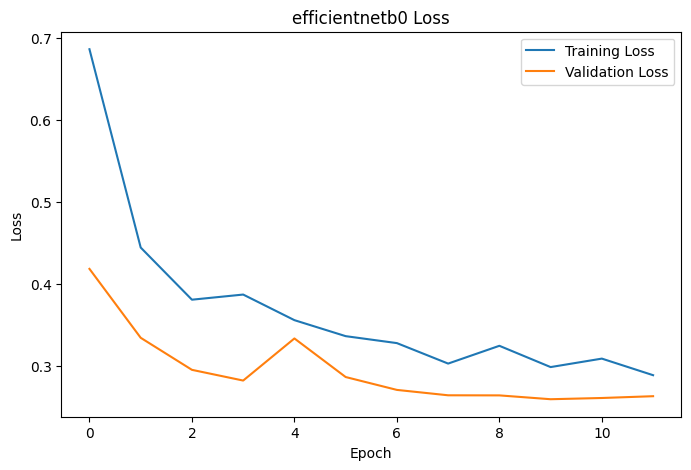

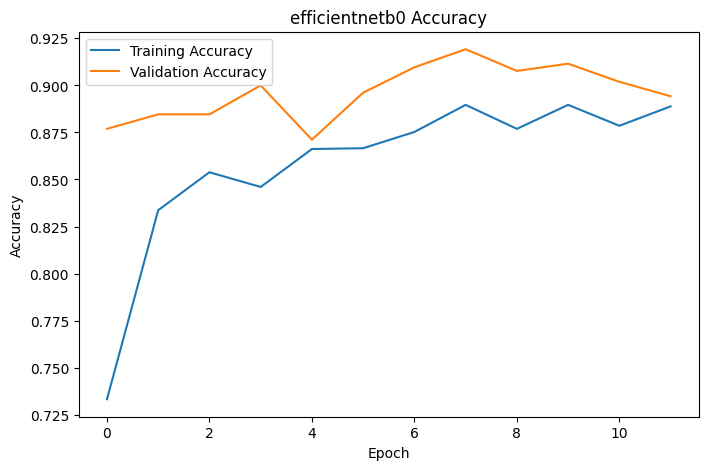

In [29]:
def plot_history(history, title_prefix="Model"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history, title_prefix=CONFIG["MODEL_NAME"])

## 20. Optional Fine-Tuning

Base model found: efficientnetb0
Total base model layers: 238
Trainable base model layers: 23
Epoch 1/8


E0000 00:00:1779970646.089860      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8760 - loss: 0.2862
Epoch 1: val_loss improved from inf to 0.26220, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.8760 - loss: 0.2863 - val_accuracy: 0.9077 - val_loss: 0.2622 - learning_rate: 1.0000e-05
Epoch 2/8
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8956 - loss: 0.2646
Epoch 2: val_loss improved from 0.26220 to 0.25333, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8956 - loss: 0.2649 - val_accuracy: 0.9154 - val_loss: 0.2533 - learning_rate: 1.0000e-05
Epoch 3/8
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8863 - loss: 0.2914
Epoch 3: val_loss did not improve from 0.25333
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8864 - loss: 0.2912 - val_accuracy: 0.9135 - val_loss: 0.2613 - learning_rate: 1.0000e-05
Epoch 4/8
151/

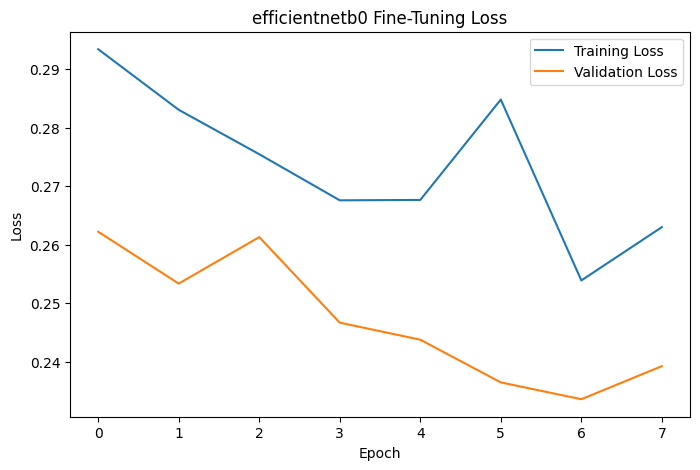

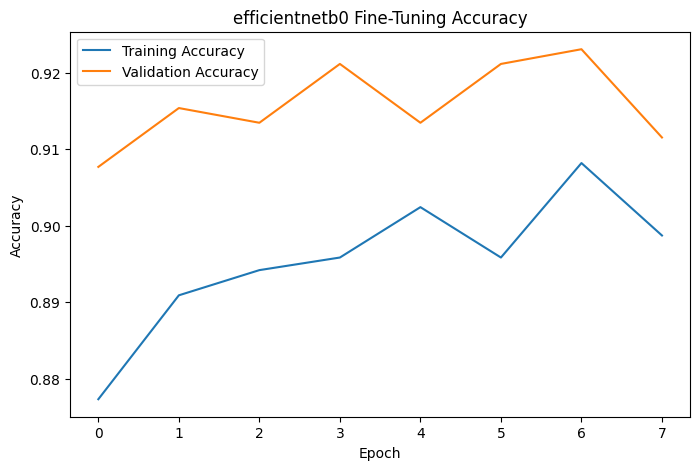

In [30]:
def fine_tune_transfer_model(model, config):
    model_name = config["MODEL_NAME"]

    if model_name == "custom_cnn":
        print("Skipping fine-tuning because custom_cnn has no pretrained base.")
        return model, None

    if not config["DO_FINE_TUNE"]:
        print("Fine-tuning disabled.")
        return model, None

    base_model = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.lower() in ["efficientnetb0", "resnet50", "densenet121"]:
                base_model = layer
                break

    if base_model is None:
        print("Could not find pretrained base model. Skipping fine-tuning.")
        return model, None

    print("Base model found:", base_model.name)
    print("Total base model layers:", len(base_model.layers))

    base_model.trainable = True

    fine_tune_at = max(
        0,
        len(base_model.layers) - config["FINE_TUNE_LAST_N_LAYERS"]
    )

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Keep BatchNorm frozen for stability on small medical image datasets.
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    trainable_base_layers = sum(
        1 for layer in base_model.layers if layer.trainable
    )

    print("Trainable base model layers:", trainable_base_layers)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["FINE_TUNE_LEARNING_RATE"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    fine_tune_history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=config["FINE_TUNE_EPOCHS"],
        class_weight=class_weights,
        callbacks=fine_tune_callbacks,
        verbose=1
    )

    return model, fine_tune_history


model, fine_tune_history = fine_tune_transfer_model(model, CONFIG)

if fine_tune_history is not None:
    plot_history(
        fine_tune_history,
        title_prefix=f"{CONFIG['MODEL_NAME']} Fine-Tuning"
    )

## 21. Load Best Model 

In [31]:
best_model = keras.models.load_model(
    checkpoint_path,
    compile=False,
    custom_objects={
        "ApplicationPreprocessing": ApplicationPreprocessing
    }
)

best_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["FINE_TUNE_LEARNING_RATE"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Loaded best model from:")
print(checkpoint_path)

Loaded best model from:
/kaggle/working/lung_xray_project/efficientnetb0_best.keras


## 22. Evaluate on Test Set

In [32]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9017 - loss: 0.2711
Test Loss: 0.29997000098228455
Test Accuracy: 0.8982725739479065


## 23. Generate Predictions 

In [33]:
y_true = test_df["label_id"].values

y_proba = best_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_proba, axis=1)

print("y_true shape:", y_true.shape)
print("y_proba shape:", y_proba.shape)
print("y_pred shape:", y_pred.shape)

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step
y_true shape: (521,)
y_proba shape: (521, 3)
y_pred shape: (521,)


## 24. Classification Reports 

In [34]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

,precision,recall,f1-score,support
Lung_Opacity,0.864407,0.905325,0.884393,169.000000
Normal,0.896552,0.829787,0.861878,188.000000
Viral Pneumonia,0.935294,0.969512,0.952096,164.000000
accuracy,0.898273,0.898273,0.898273,0.898273
macro avg,0.898751,0.901542,0.899456,521.000000
weighted avg,0.898320,0.898273,0.897580,521.000000


                 precision    recall  f1-score   support

   Lung_Opacity       0.86      0.91      0.88       169
         Normal       0.90      0.83      0.86       188
Viral Pneumonia       0.94      0.97      0.95       164

       accuracy                           0.90       521
      macro avg       0.90      0.90      0.90       521
   weighted avg       0.90      0.90      0.90       521



## 25. Confusion Matrix 

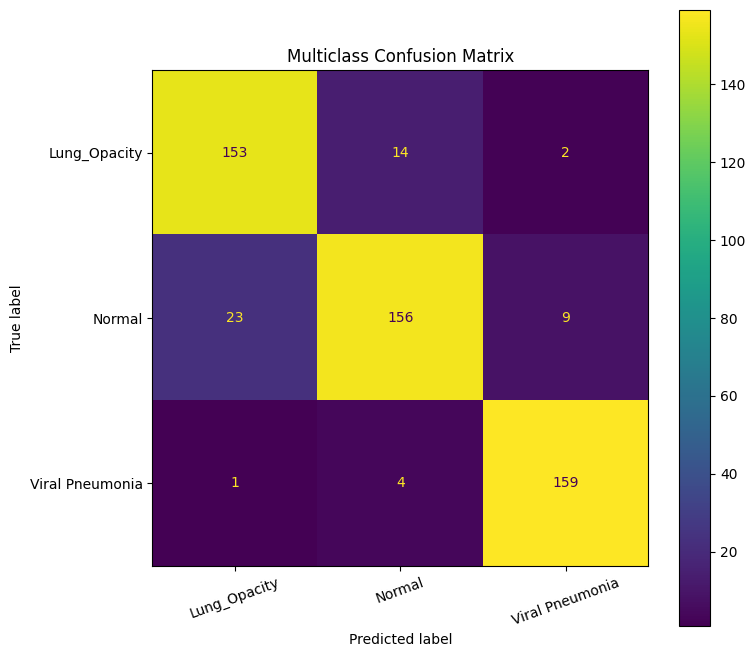

In [35]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Multiclass Confusion Matrix")
plt.xticks(rotation=20)
plt.show()

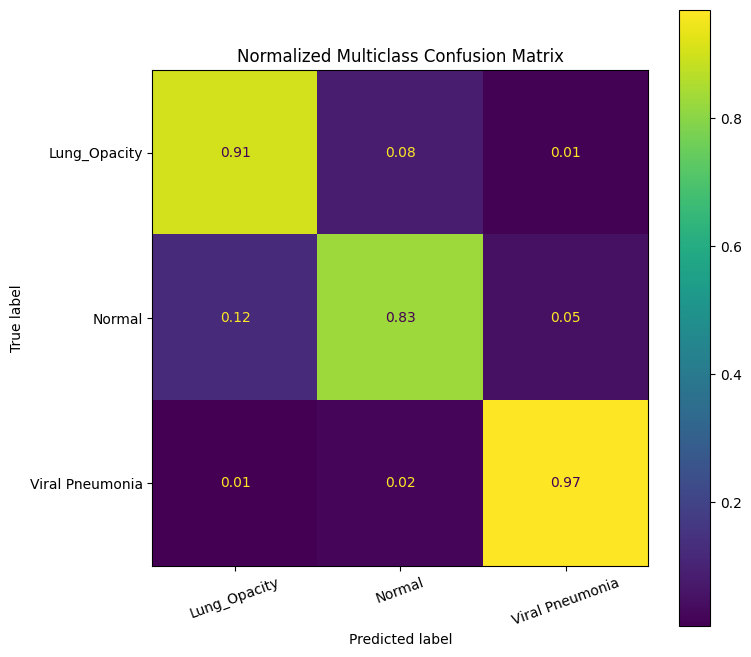

In [36]:
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format=".2f")
plt.title("Normalized Multiclass Confusion Matrix")
plt.xticks(rotation=20)
plt.show()

## 26. Multi-Class ROC AUC 

In [37]:
macro_roc_auc = None
weighted_roc_auc = None

try:
    macro_roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    weighted_roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    print("Macro ROC-AUC:", macro_roc_auc)
    print("Weighted ROC-AUC:", weighted_roc_auc)

except Exception as e:
    print("Could not calculate ROC-AUC.")
    print(e)

Macro ROC-AUC: 0.9744504942686681
Weighted ROC-AUC: 0.9736990513389123


## 27. ROC Curves 

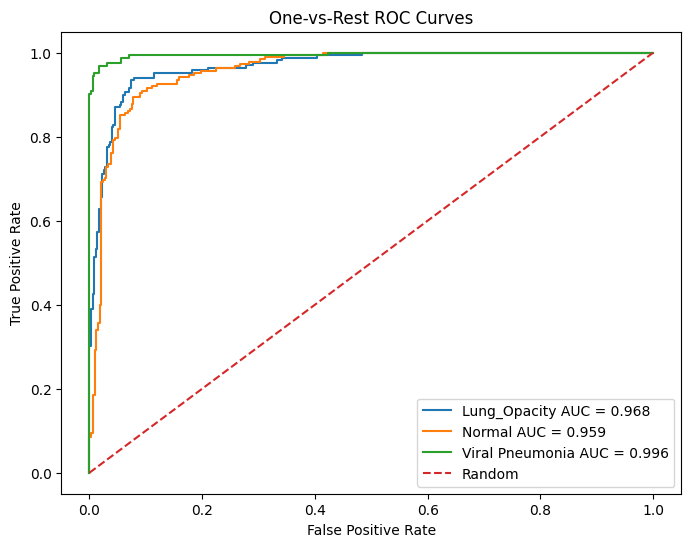

In [38]:
y_true_bin = label_binarize(
    y_true,
    classes=list(range(NUM_CLASSES))
)

plt.figure(figsize=(8, 6))

for class_idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, class_idx],
        y_proba[:, class_idx]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {class_auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.title("One-vs-Rest ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 28. Binary Evaluation: Normal vs. Abnormal 

Binary task:
0 = Normal
1 = Abnormal

Classification report using threshold = 0.50
              precision    recall  f1-score   support

      Normal       0.90      0.83      0.86       188
    Abnormal       0.91      0.95      0.93       333

    accuracy                           0.90       521
   macro avg       0.90      0.89      0.89       521
weighted avg       0.90      0.90      0.90       521

Binary ROC-AUC: 0.9593955657785445


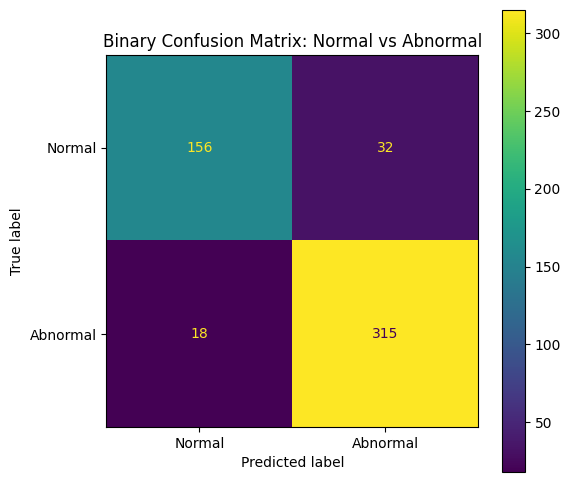

In [39]:
normal_id = class_to_id["Normal"]

y_true_binary = np.where(y_true == normal_id, 0, 1)

# Abnormal probability = probability of all non-normal classes.
y_proba_binary = 1.0 - y_proba[:, normal_id]

default_binary_threshold = 0.50

y_pred_binary_default = (
    y_proba_binary >= default_binary_threshold
).astype(int)

print("Binary task:")
print("0 = Normal")
print("1 = Abnormal")

print("\nClassification report using threshold = 0.50")
print(
    classification_report(
        y_true_binary,
        y_pred_binary_default,
        target_names=["Normal", "Abnormal"]
    )
)

binary_auc = roc_auc_score(
    y_true_binary,
    y_proba_binary
)

print("Binary ROC-AUC:", binary_auc)

binary_cm = confusion_matrix(
    y_true_binary,
    y_pred_binary_default
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=binary_cm,
    display_labels=["Normal", "Abnormal"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Binary Confusion Matrix: Normal vs Abnormal")
plt.show()

## 29. Threshhold Tuning on Validation Set 

In [40]:
best_threshold = 0.50
threshold_df = None

if CONFIG["RUN_THRESHOLD_TUNING"]:
    valid_y_true = valid_df["label_id"].values

    valid_y_proba = best_model.predict(
        valid_ds,
        verbose=1
    )

    valid_y_true_binary = np.where(valid_y_true == normal_id, 0, 1)
    valid_y_proba_binary = 1.0 - valid_y_proba[:, normal_id]

    threshold_results = []

    for threshold in np.arange(0.10, 0.91, 0.01):
        valid_y_pred_binary = (
            valid_y_proba_binary >= threshold
        ).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            valid_y_true_binary,
            valid_y_pred_binary,
            average="binary",
            zero_division=0
        )

        threshold_results.append({
            "threshold": float(threshold),
            "precision_abnormal": float(precision),
            "recall_abnormal": float(recall),
            "f1_abnormal": float(f1)
        })

    threshold_df = pd.DataFrame(threshold_results)

    print("Top thresholds by abnormal F1:")
    display(
        threshold_df.sort_values(
            by="f1_abnormal",
            ascending=False
        ).head(20)
    )

    best_threshold = float(
        threshold_df.sort_values(
            by="f1_abnormal",
            ascending=False
        ).iloc[0]["threshold"]
    )

print("Selected abnormal threshold:", best_threshold)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Top thresholds by abnormal F1:


,threshold,precision_abnormal,recall_abnormal,f1_abnormal
39,0.49,0.945946,0.945946,0.945946
42,0.52,0.948485,0.939940,0.944193
43,0.53,0.948485,0.939940,0.944193
38,0.48,0.940299,0.945946,0.943114
41,0.51,0.945619,0.939940,0.942771
40,0.50,0.945619,0.939940,0.942771
36,0.46,0.932353,0.951952,0.942051
35,0.45,0.932353,0.951952,0.942051
37,0.47,0.934911,0.948949,0.941878
45,0.55,0.948171,0.933934,0.940998


Selected abnormal threshold: 0.48999999999999977


## 30. Test Binary Evaluation with Tuned Threshhold 

Classification report using tuned threshold = 0.49
              precision    recall  f1-score   support

      Normal       0.90      0.83      0.86       188
    Abnormal       0.91      0.95      0.93       333

    accuracy                           0.90       521
   macro avg       0.90      0.89      0.89       521
weighted avg       0.90      0.90      0.90       521



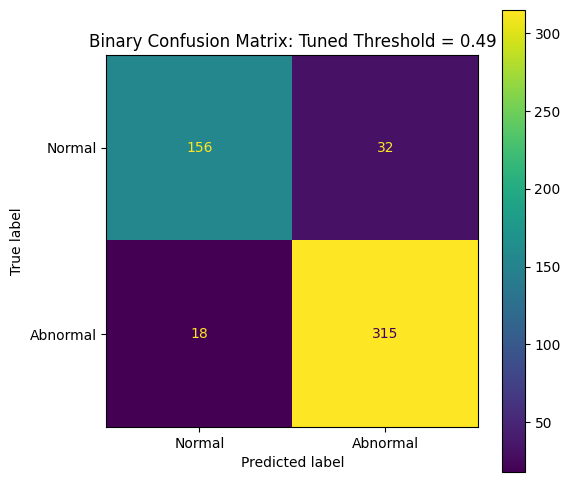

In [41]:
y_pred_binary_tuned = (
    y_proba_binary >= best_threshold
).astype(int)

print(f"Classification report using tuned threshold = {best_threshold:.2f}")

print(
    classification_report(
        y_true_binary,
        y_pred_binary_tuned,
        target_names=["Normal", "Abnormal"]
    )
)

binary_cm_tuned = confusion_matrix(
    y_true_binary,
    y_pred_binary_tuned
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=binary_cm_tuned,
    display_labels=["Normal", "Abnormal"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Binary Confusion Matrix: Tuned Threshold = {best_threshold:.2f}")
plt.show()

## 31. Error Analysis Table 

In [42]:
error_df = test_df.copy()

error_df["true_id"] = y_true
error_df["pred_id"] = y_pred

error_df["true_label"] = error_df["true_id"].map(id_to_class)
error_df["pred_label"] = error_df["pred_id"].map(id_to_class)

error_df["confidence"] = np.max(y_proba, axis=1)
error_df["is_correct"] = error_df["true_id"] == error_df["pred_id"]

misclassified_df = (
    error_df[error_df["is_correct"] == False]
    .sort_values("confidence", ascending=False)
)

print("Total test images:", len(error_df))
print("Correct predictions:", int(error_df["is_correct"].sum()))
print("Misclassified images:", len(misclassified_df))

display(misclassified_df.head(20))

Total test images: 521
Correct predictions: 468
Misclassified images: 53


,filepath,label,width,height,mode,file_hash,label_id,true_id,pred_id,true_label,pred_label,confidence,is_correct
255,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,209b46a4124d87f3d727bcea1f4371f7,0,0,1,Lung_Opacity,Normal,0.996646,False
426,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,bd6d5f676216cbe7d6bb88ec4d8b0e6c,1,1,0,Normal,Lung_Opacity,0.995944,False
42,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,7ce6f640089ba66dd4ea9173968907d8,2,2,1,Viral Pneumonia,Normal,0.995883,False
111,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,61e430962aeab541ec16aeecdd8232d8,1,1,0,Normal,Lung_Opacity,0.992426,False
436,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,28f8584370aa268429a806b95b51c6d3,0,0,1,Lung_Opacity,Normal,0.990659,False
413,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,2f83315bf7ddf435b3695d169ad731f4,1,1,0,Normal,Lung_Opacity,0.990498,False
325,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,cc6ddb94111875f41995d3f3dbc9c0be,1,1,0,Normal,Lung_Opacity,0.983667,False
330,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,85e5133e64ca3fb0b76263bf5b5cfdd5,1,1,0,Normal,Lung_Opacity,0.981585,False
189,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,47162d7814984681aa0c26a61813aaad,0,0,1,Lung_Opacity,Normal,0.979244,False
418,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,1cdbd2d59408e56fa6bab617cc5d8f21,1,1,0,Normal,Lung_Opacity,0.978091,False


## 32. Confidence Analysis 

,count,mean,std,min,25%,50%,75%,max
is_correct,,,,,,,,
False,53.0,0.804965,0.163652,0.467860,0.671493,0.839798,0.966283,0.996646
True,468.0,0.952426,0.088555,0.525152,0.948281,0.992116,0.999550,1.000000


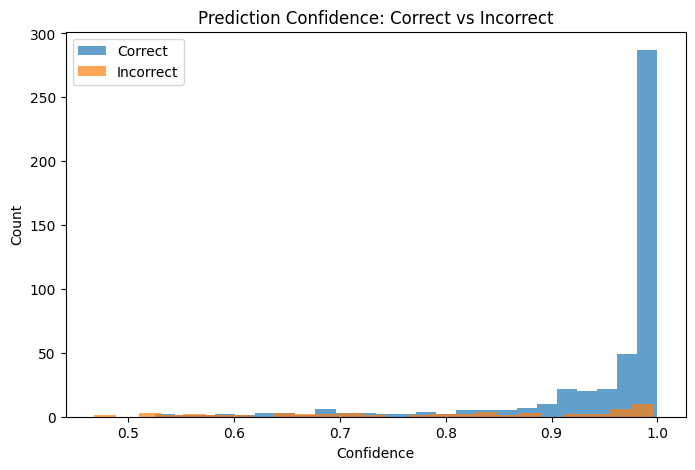

High-confidence errors with confidence >= 0.90: 20


,filepath,label,width,height,mode,file_hash,label_id,true_id,pred_id,true_label,pred_label,confidence,is_correct
255,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,209b46a4124d87f3d727bcea1f4371f7,0,0,1,Lung_Opacity,Normal,0.996646,False
426,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,bd6d5f676216cbe7d6bb88ec4d8b0e6c,1,1,0,Normal,Lung_Opacity,0.995944,False
42,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,7ce6f640089ba66dd4ea9173968907d8,2,2,1,Viral Pneumonia,Normal,0.995883,False
111,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,61e430962aeab541ec16aeecdd8232d8,1,1,0,Normal,Lung_Opacity,0.992426,False
436,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,28f8584370aa268429a806b95b51c6d3,0,0,1,Lung_Opacity,Normal,0.990659,False
413,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,2f83315bf7ddf435b3695d169ad731f4,1,1,0,Normal,Lung_Opacity,0.990498,False
325,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,cc6ddb94111875f41995d3f3dbc9c0be,1,1,0,Normal,Lung_Opacity,0.983667,False
330,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,85e5133e64ca3fb0b76263bf5b5cfdd5,1,1,0,Normal,Lung_Opacity,0.981585,False
189,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,47162d7814984681aa0c26a61813aaad,0,0,1,Lung_Opacity,Normal,0.979244,False
418,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,1cdbd2d59408e56fa6bab617cc5d8f21,1,1,0,Normal,Lung_Opacity,0.978091,False


In [43]:
confidence_summary = error_df.groupby("is_correct")["confidence"].describe()
display(confidence_summary)

plt.figure(figsize=(8, 5))
plt.hist(
    error_df[error_df["is_correct"] == True]["confidence"],
    bins=25,
    alpha=0.7,
    label="Correct"
)
plt.hist(
    error_df[error_df["is_correct"] == False]["confidence"],
    bins=25,
    alpha=0.7,
    label="Incorrect"
)
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.legend()
plt.show()


# High-confidence errors
high_confidence_errors = misclassified_df[
    misclassified_df["confidence"] >= 0.90
]

print("High-confidence errors with confidence >= 0.90:", len(high_confidence_errors))
display(high_confidence_errors.head(20))

## 33. Visualize Misclassifications 

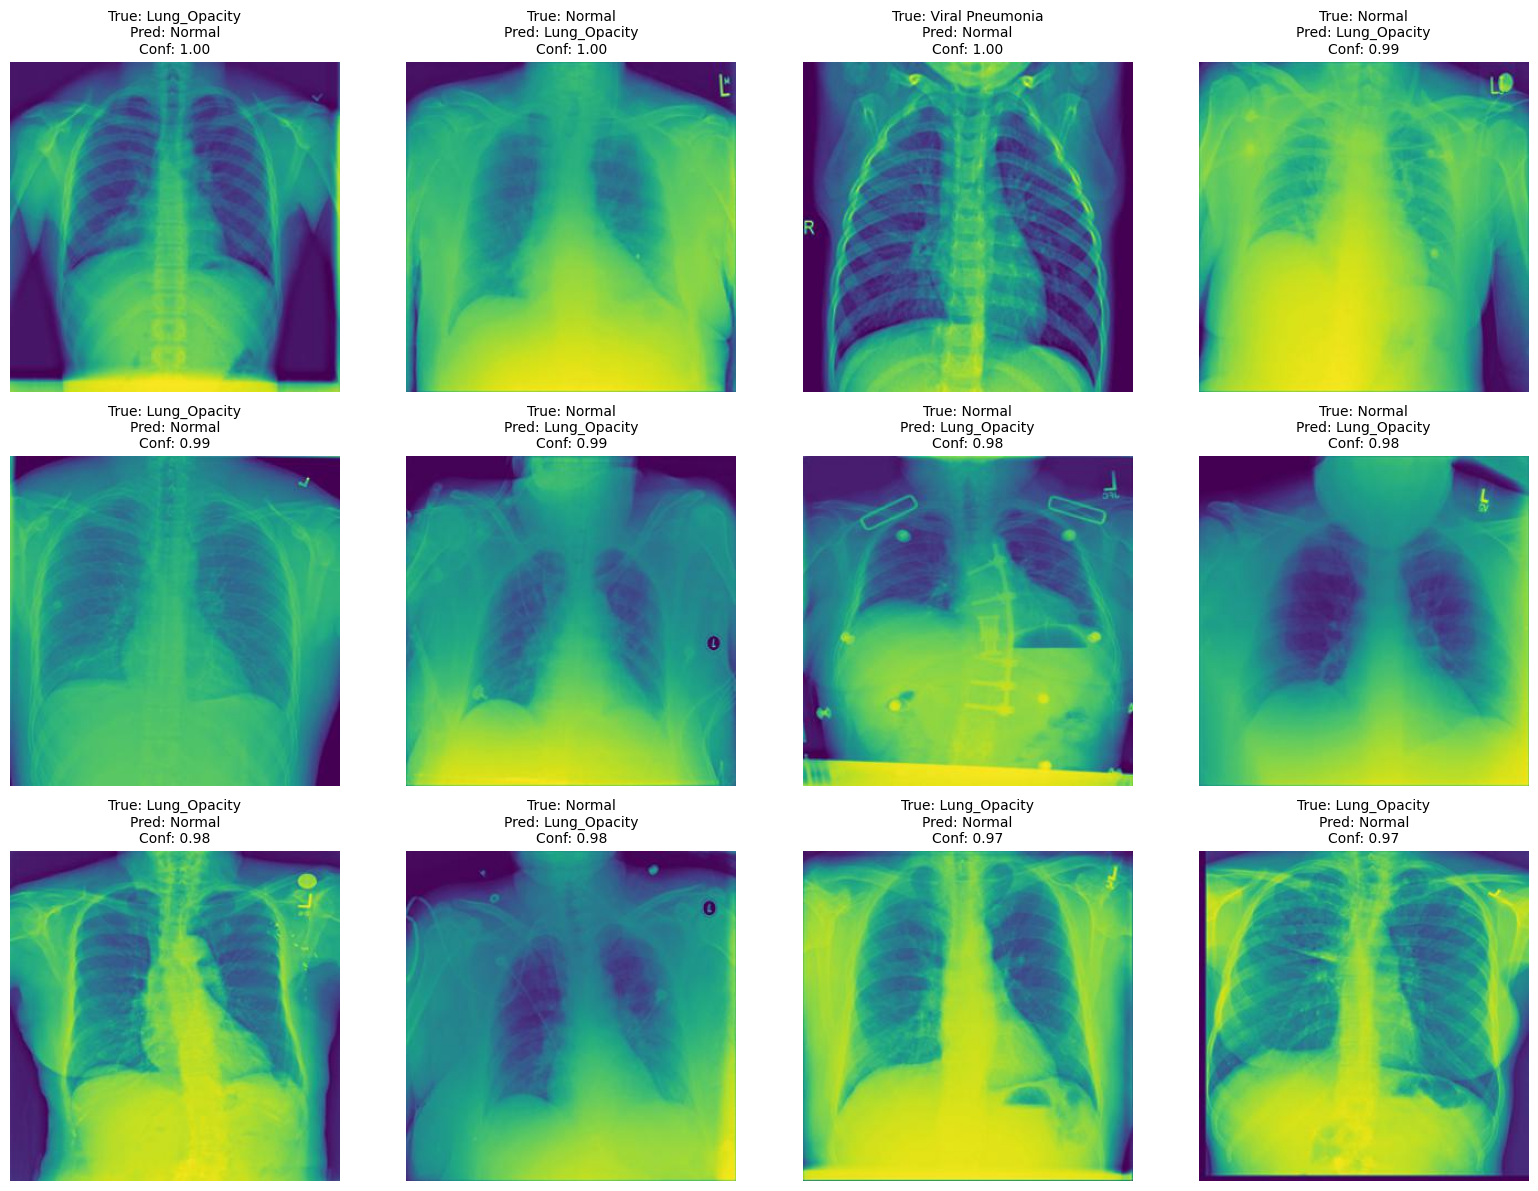

In [44]:
def show_prediction_grid(dataframe, max_images=12):
    if len(dataframe) == 0:
        print("No images to display.")
        return

    sample_df = dataframe.head(max_images)

    cols = 4
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["filepath"]).convert("RGB")

        plt.subplot(rows, cols, idx)
        plt.imshow(img)
        plt.axis("off")

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['pred_label']}\n"
            f"Conf: {row['confidence']:.2f}"
        )

        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


show_prediction_grid(
    misclassified_df,
    max_images=12
)

## 34. Visualize Correct High-Confidence Predictions 

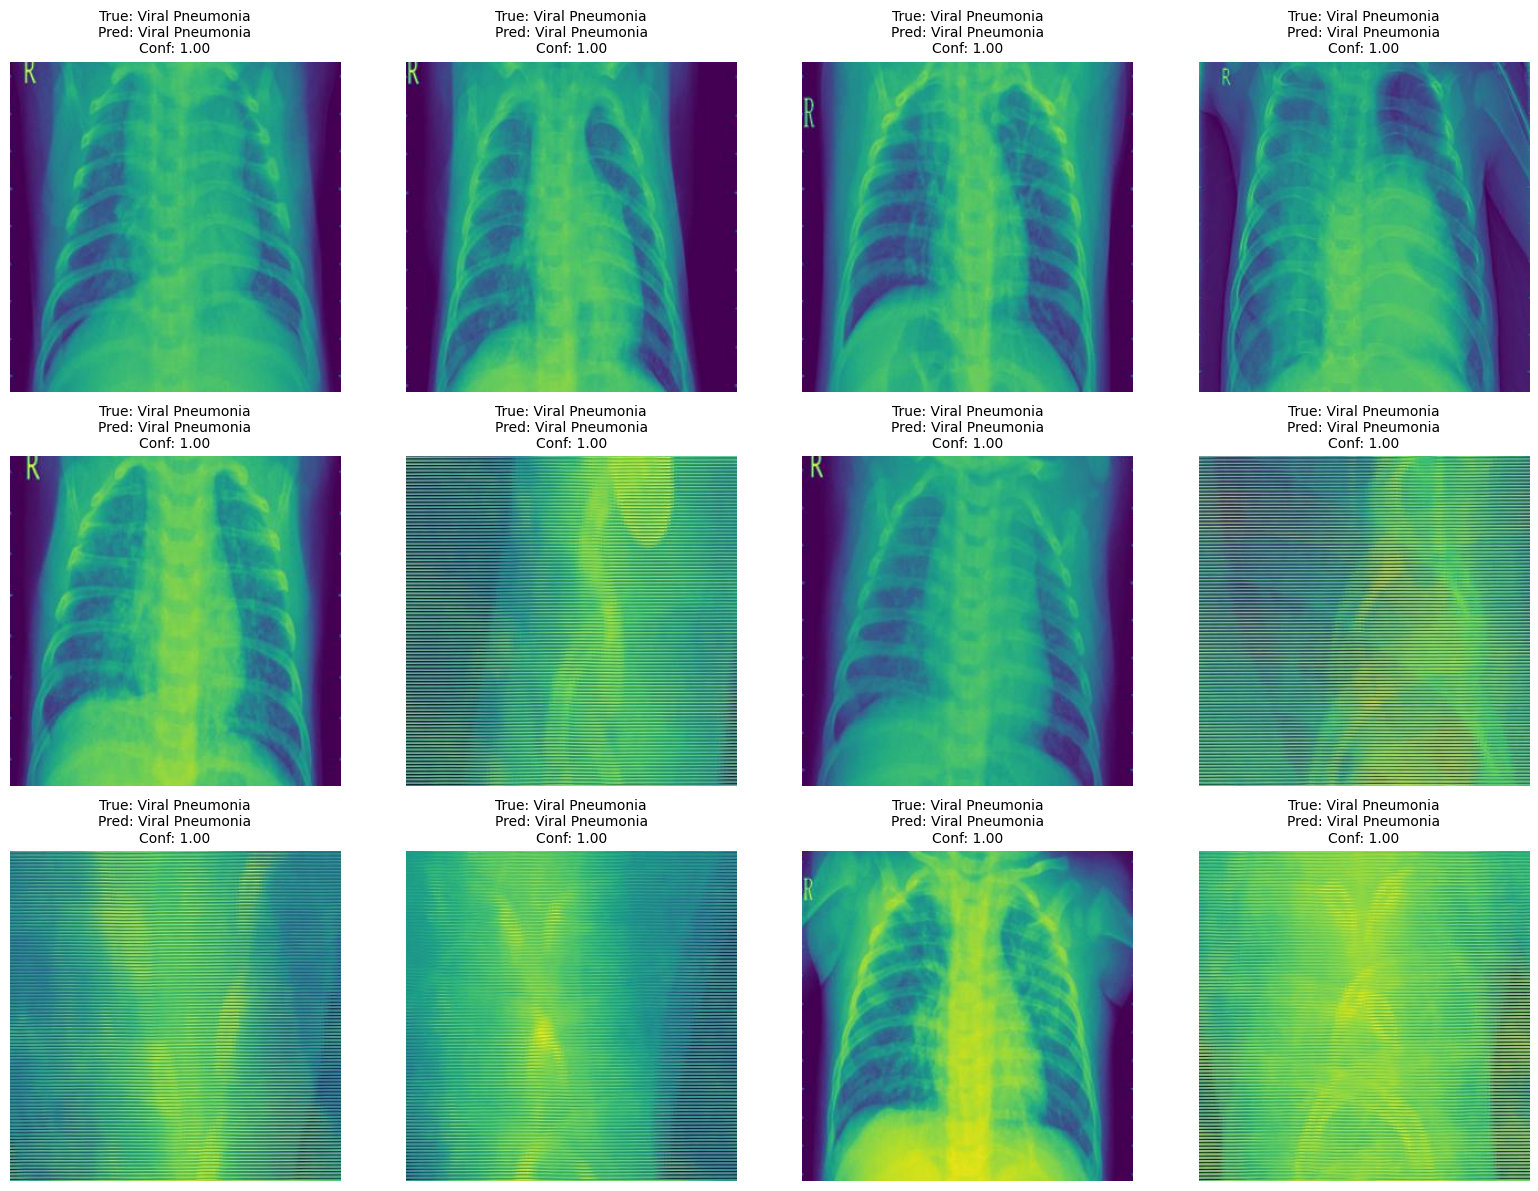

In [45]:
correct_df = (
    error_df[error_df["is_correct"] == True]
    .sort_values("confidence", ascending=False)
)

show_prediction_grid(
    correct_df,
    max_images=12
)

## 35. Single Image Inference Function 

{
    "image_path": "/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Normal/1082.jpg",
    "predicted_label": "Normal",
    "confidence": 0.9735633134841919,
    "probabilities": {
        "Lung_Opacity": 0.02623887173831463,
        "Normal": 0.9735633134841919,
        "Viral Pneumonia": 0.00019772752420976758
    }
}


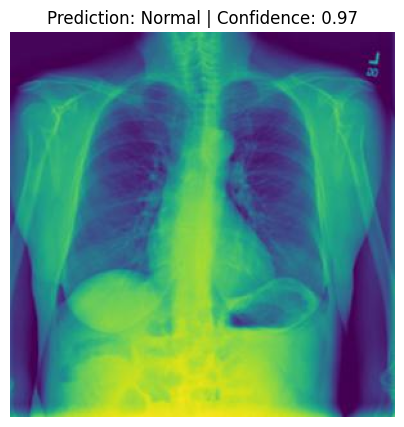

In [46]:
def predict_single_image(
    model,
    image_path,
    class_names,
    image_size=CONFIG["IMAGE_SIZE"]
):
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize(image_size)

    array = np.array(image_resized).astype(np.float32)
    array = np.expand_dims(array, axis=0)

    probabilities = model.predict(array, verbose=0)[0]

    pred_id = int(np.argmax(probabilities))
    pred_label = class_names[pred_id]
    confidence = float(probabilities[pred_id])

    result = {
        "image_path": image_path,
        "predicted_label": pred_label,
        "confidence": confidence,
        "probabilities": {
            class_names[i]: float(probabilities[i])
            for i in range(len(class_names))
        }
    }

    return result


example_path = test_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

prediction = predict_single_image(
    best_model,
    example_path,
    class_names
)

print(json.dumps(prediction, indent=4))

img = Image.open(example_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {prediction['predicted_label']} | "
    f"Confidence: {prediction['confidence']:.2f}"
)
plt.show()

## 36. Grad-CAM Explainability 

Image: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Normal/1082.jpg
True label: Normal


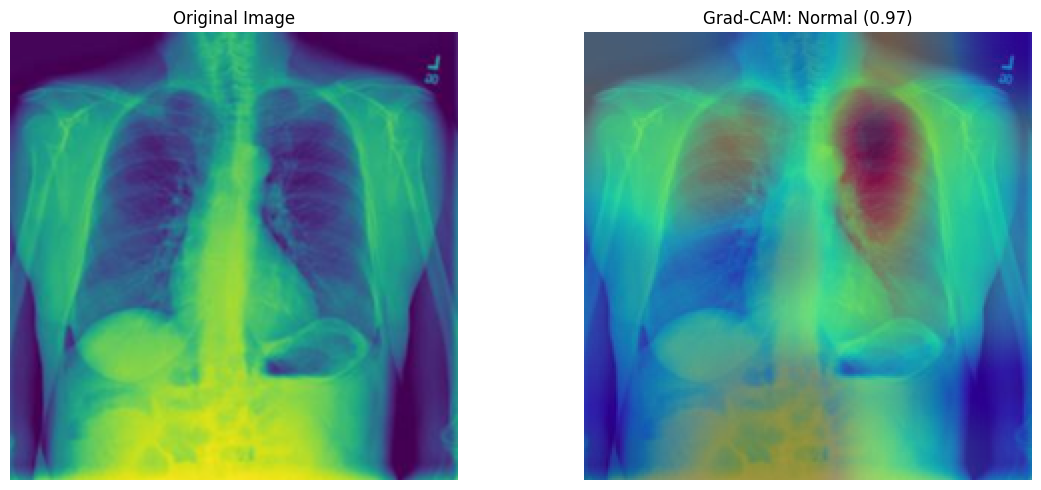

Image: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Viral Pneumonia/747.jpg
True label: Viral Pneumonia


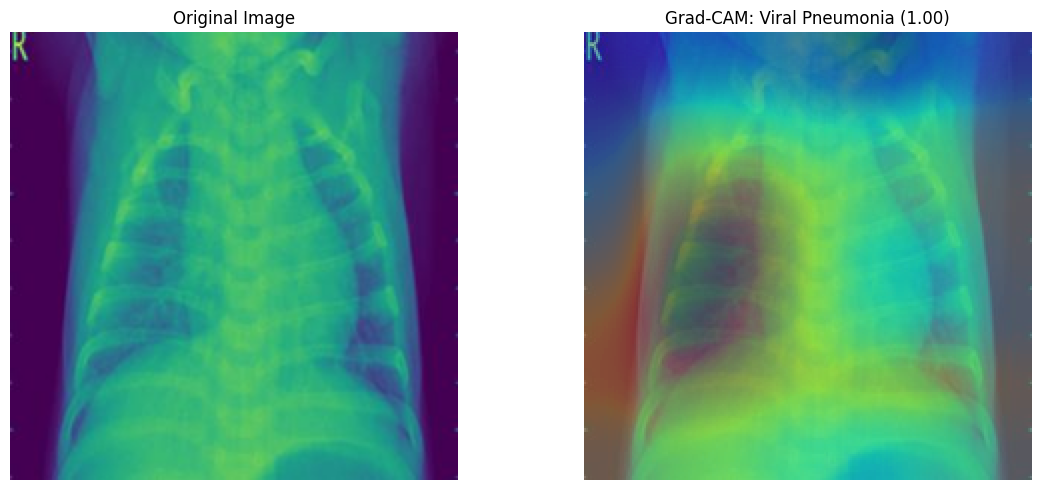

Image: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Normal/97.jpg
True label: Normal


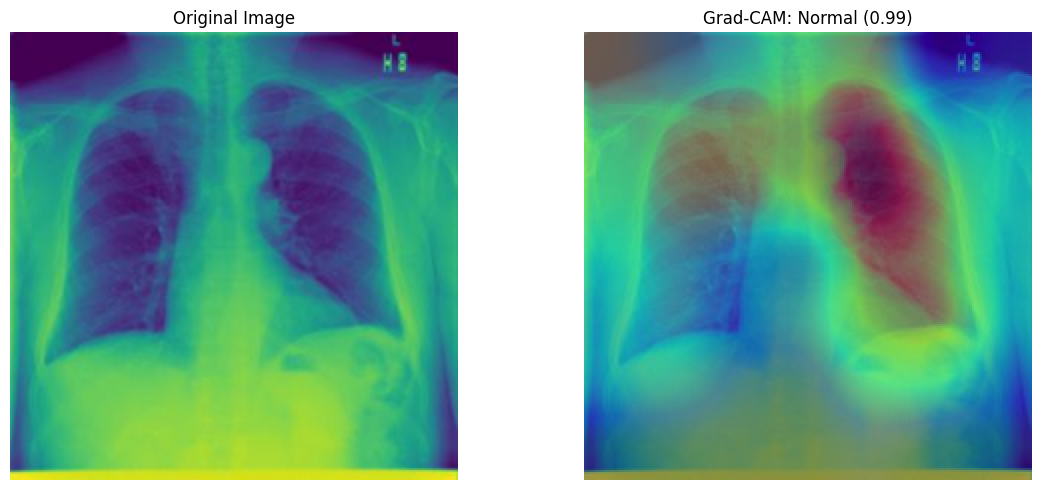

Image: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Lung_Opacity/317.jpg
True label: Lung_Opacity


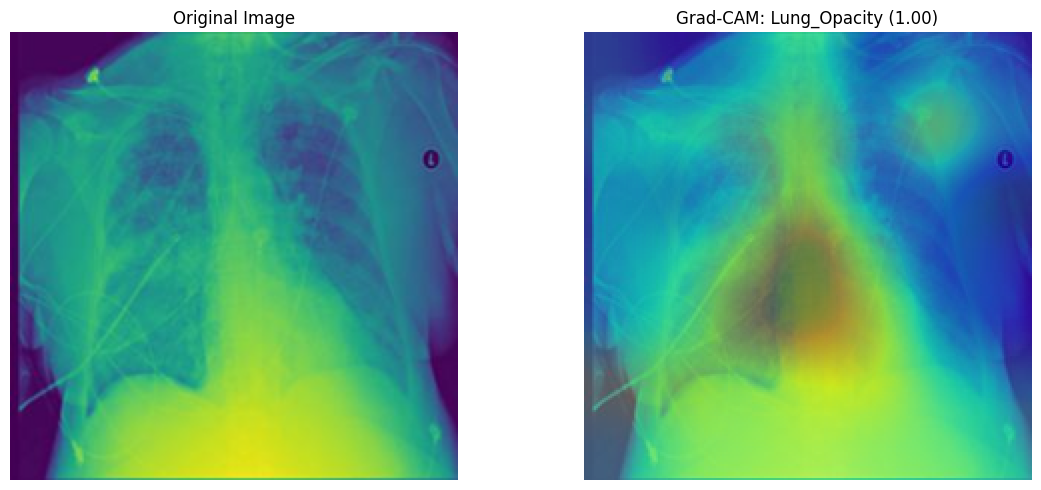

In [47]:
def find_base_model(model):
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.lower() in ["efficientnetb0", "resnet50", "densenet121"]:
                return layer
    return None


def find_last_conv_layer_name(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name

    # Fallback for architectures where the last useful spatial layer
    # may not be a direct Conv2D layer.
    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except Exception:
            continue

    return None


def apply_layer_safely(layer, x, training=False):
    # InputLayer should not be manually called.
    if isinstance(layer, layers.InputLayer):
        return x

    try:
        return layer(x, training=training)
    except TypeError:
        return layer(x)


def make_image_tensor(image_path, image_size=CONFIG["IMAGE_SIZE"]):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)

    array = np.array(image).astype(np.float32)
    array = np.expand_dims(array, axis=0)

    return array


def make_gradcam_heatmap(model, image_array, class_index=None):
    base_model = find_base_model(model)

    if base_model is None:
        raise ValueError(
            "Grad-CAM is currently implemented for transfer models only."
        )

    last_conv_layer_name = find_last_conv_layer_name(base_model)

    if last_conv_layer_name is None:
        raise ValueError(
            "Could not find a convolutional/spatial layer for Grad-CAM."
        )

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    feature_extractor = keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    # Pass image through the outer model until the pretrained base model.
    x = tf.convert_to_tensor(image_array)

    base_model_layer_index = None

    for idx, layer in enumerate(model.layers):
        if layer is base_model:
            base_model_layer_index = idx
            break

        # Skip InputLayer. It cannot be called like a normal layer.
        if isinstance(layer, layers.InputLayer):
            continue

        x = apply_layer_safely(layer, x, training=False)

    if base_model_layer_index is None:
        raise ValueError("Could not locate base model inside full model.")

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = feature_extractor(x, training=False)

        y = base_outputs

        # Pass base model output through the classifier head.
        for layer in model.layers[base_model_layer_index + 1:]:
            if isinstance(layer, layers.InputLayer):
                continue

            y = apply_layer_safely(layer, y, training=False)

        if class_index is None:
            class_index = tf.argmax(y[0])

        class_score = y[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError(
            "Could not compute gradients for Grad-CAM. "
            "Try using a different convolutional layer."
        )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if float(max_value.numpy()) == 0.0:
        return np.zeros_like(heatmap.numpy())

    heatmap = heatmap / max_value

    return heatmap.numpy()


def display_gradcam(
    model,
    image_path,
    class_names,
    alpha=0.35,
    image_size=CONFIG["IMAGE_SIZE"]
):
    image_array = make_image_tensor(
        image_path,
        image_size=image_size
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    pred_id = int(np.argmax(probabilities))
    pred_label = class_names[pred_id]
    confidence = float(probabilities[pred_id])

    heatmap = make_gradcam_heatmap(
        model,
        image_array,
        class_index=pred_id
    )

    original_img = Image.open(image_path).convert("RGB")
    original_img = original_img.resize(image_size)
    original_array = np.array(original_img)

    heatmap_resized = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize(image_size)

    heatmap_resized = np.array(heatmap_resized)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_array)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(original_array)
    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=alpha
    )
    plt.title(f"Grad-CAM: {pred_label} ({confidence:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Display Grad-CAM for several test images.
gradcam_examples = test_df.sample(
    n=min(4, len(test_df)),
    random_state=SEED
)

for _, row in gradcam_examples.iterrows():
    print("Image:", row["filepath"])
    print("True label:", row["label"])

    display_gradcam(
        best_model,
        row["filepath"],
        class_names
    )

## 37. Save Metrics 

In [48]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

metrics = {
    "model_name": CONFIG["MODEL_NAME"],
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
    "macro_roc_auc": None if macro_roc_auc is None else float(macro_roc_auc),
    "weighted_roc_auc": None if weighted_roc_auc is None else float(weighted_roc_auc),
    "binary_roc_auc": float(binary_auc),
    "binary_default_threshold": float(default_binary_threshold),
    "binary_tuned_threshold": float(best_threshold),
    "class_names": class_names,
    "class_mapping": class_to_id,
    "config": CONFIG
}

metrics_path = f"{CONFIG['OUTPUT_DIR']}/{CONFIG['MODEL_NAME']}_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:")
print(metrics_path)

metrics

Saved metrics to:
/kaggle/working/lung_xray_project/efficientnetb0_metrics.json


{'model_name': 'efficientnetb0',
 'test_loss': 0.29997000098228455,
 'test_accuracy': 0.8982725739479065,
 'weighted_precision': 0.8983199715830337,
 'weighted_recall': 0.8982725527831094,
 'weighted_f1': 0.8975802101569785,
 'macro_roc_auc': 0.9744504942686681,
 'weighted_roc_auc': 0.9736990513389123,
 'binary_roc_auc': 0.9593955657785445,
 'binary_default_threshold': 0.5,
 'binary_tuned_threshold': 0.48999999999999977,
 'class_names': ['Lung_Opacity', 'Normal', 'Viral Pneumonia'],
 'class_mapping': {'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2},
 'config': {'MODEL_NAME': 'efficientnetb0',
  'DATA_DIR': '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image',
  'IMAGE_SIZE': (224, 224),
  'BATCH_SIZE': 16,
  'EPOCHS': 12,
  'FINE_TUNE_EPOCHS': 8,
  'VALID_SIZE': 0.15,
  'TEST_SIZE': 0.15,
  'LEARNING_RATE': 0.0001,
  'FINE_TUNE_LEARNING_RATE': 1e-05,
  'DROPOUT': 0.35,
  'DENSE_UNITS': 256,
  'DO_FINE_TUNE': True,
  'FINE_TUNE_LAST_N_LAYERS': 

## 38. Save Final Model and Label Map 

In [49]:
Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

# Define output paths
final_model_path = f"{CONFIG['OUTPUT_DIR']}/{CONFIG['MODEL_NAME']}_final.keras"
label_map_path = f"{CONFIG['OUTPUT_DIR']}/label_map.json"
metrics_path = f"{CONFIG['OUTPUT_DIR']}/{CONFIG['MODEL_NAME']}_metrics.json"

# Save final model
best_model.save(final_model_path)

# Save label map
with open(label_map_path, "w") as f:
    json.dump(
        {
            "class_to_id": class_to_id,
            "id_to_class": {str(k): v for k, v in id_to_class.items()}
        },
        f,
        indent=4
    )

print("Saved final model to:")
print(final_model_path)

print("\nSaved label map to:")
print(label_map_path)

Saved final model to:
/kaggle/working/lung_xray_project/efficientnetb0_final.keras

Saved label map to:
/kaggle/working/lung_xray_project/label_map.json
